Cell 0 – Install Required Packages

In [1]:
!pip install --quiet biopython numpy matplotlib
!apt-get update
!apt-get install -y clustalo
!clustalo --version
!pip install --quiet scipy

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
clustalo is already the newest version (1.2.4-7).
0 upgraded, 0 newly installed, 0 to remove a

Cell 1 – Import Libraries

In [2]:
import numpy as np
import math
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
import subprocess
import os
from Bio import SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment
import pandas as pd
from typing import List, Optional
from pathlib import Path
import seaborn as sns
import subprocess
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

Cell 2 – FASTA Reading and Writing Utilities

In [3]:
# read_fasta: reads a FASTA file using Biopython SeqIO and returns a tuple of names and sequences
# write_alignment: saves an MSA (multiple sequence alignment) to a FASTA file with sequence names

from typing import List, Tuple

def read_fasta(filename: str) -> Tuple[List[str], List[str]]:
    names, seqs = [], []
    for record in SeqIO.parse(filename, "fasta"):
        names.append(record.id)         # store sequence ID
        seqs.append(str(record.seq))    # store sequence string
    return names, seqs

def write_alignment(names: List[str], alignment: List[str], out_file: str):
    with open(out_file, "w") as f:
        for name, seq in zip(names, alignment):
            f.write(f">{name}\n{seq}\n")
    print("Saved alignment to:", out_file)


Cell 3 – BLOSUM62 and Amino Acid Scoring

In [4]:
# BLOSUM62: dictionary representing the BLOSUM62 substitution matrix for amino acids
# blosum62_score: returns the substitution score for a pair of residues; uses a default penalty if unknown

from typing import Dict

BLOSUM62: Dict[str, Dict[str, int]] = {
    "A": {"A": 4,  "R": -1, "N": -2, "D": -2, "C": 0,  "Q": -1, "E": -1, "G": 0,  "H": -2, "I": -1,
          "L": -1, "K": -1, "M": -1, "F": -2, "P": -1, "S": 1,  "T": 0,  "W": -3, "Y": -2, "V": 0},
    "R": {"A": -1, "R": 5,  "N": 0,  "D": -2, "C": -3, "Q": 1,  "E": 0,  "G": -2, "H": 0,  "I": -3,
          "L": -2, "K": 2,  "M": -1, "F": -3, "P": -2, "S": -1, "T": -1, "W": -3, "Y": -2, "V": -3},
    "N": {"A": -2, "R": 0,  "N": 6,  "D": 1,  "C": -3, "Q": 0,  "E": 0,  "G": 0,  "H": 1,  "I": -3,
          "L": -3, "K": 0,  "M": -2, "F": -3, "P": -2, "S": 1,  "T": 0,  "W": -4, "Y": -2, "V": -3},
    "D": {"A": -2, "R": -2, "N": 1,  "D": 6,  "C": -3, "Q": 0,  "E": 2,  "G": -1, "H": -1, "I": -3,
          "L": -4, "K": -1, "M": -3, "F": -3, "P": -1, "S": 0,  "T": -1, "W": -4, "Y": -3, "V": -3},
    "C": {"A": 0,  "R": -3, "N": -3, "D": -3, "C": 9,  "Q": -3, "E": -4, "G": -3, "H": -3, "I": -1,
          "L": -1, "K": -3, "M": -1, "F": -2, "P": -3, "S": -1, "T": -1, "W": -2, "Y": -2, "V": -1},
    "Q": {"A": -1, "R": 1,  "N": 0,  "D": 0,  "C": -3, "Q": 5,  "E": 2,  "G": -2, "H": 0,  "I": -3,
          "L": -2, "K": 1,  "M": 0,  "F": -3, "P": -1, "S": 0,  "T": -1, "W": -2, "Y": -1, "V": -2},
    "E": {"A": -1, "R": 0,  "N": 0,  "D": 2,  "C": -4, "Q": 2,  "E": 5,  "G": -2, "H": 0,  "I": -3,
          "L": -3, "K": 1,  "M": -2, "F": -3, "P": -1, "S": 0,  "T": -1, "W": -3, "Y": -2, "V": -2},
    "G": {"A": 0,  "R": -2, "N": 0,  "D": -1, "C": -3, "Q": -2, "E": -2, "G": 6,  "H": -2, "I": -4,
          "L": -4, "K": -2, "M": -3, "F": -3, "P": -2, "S": 0,  "T": -2, "W": -2, "Y": -3, "V": -3},
    "H": {"A": -2, "R": 0,  "N": 1,  "D": -1, "C": -3, "Q": 0,  "E": 0,  "G": -2, "H": 8,  "I": -3,
          "L": -3, "K": -1, "M": -2, "F": -1, "P": -2, "S": -1, "T": -2, "W": -2, "Y": 2,  "V": -3},
    "I": {"A": -1, "R": -3, "N": -3, "D": -3, "C": -1, "Q": -3, "E": -3, "G": -4, "H": -3, "I": 4,
          "L": 2,  "K": -3, "M": 1,  "F": 0,  "P": -3, "S": -2, "T": -1, "W": -3, "Y": -1, "V": 3},
    "L": {"A": -1, "R": -2, "N": -3, "D": -4, "C": -1, "Q": -2, "E": -3, "G": -4, "H": -3, "I": 2,
          "L": 4,  "K": -2, "M": 2,  "F": 0,  "P": -3, "S": -2, "T": -1, "W": -2, "Y": -1, "V": 1},
    "K": {"A": -1, "R": 2,  "N": 0,  "D": -1, "C": -3, "Q": 1,  "E": 1,  "G": -2, "H": -1, "I": -3,
          "L": -2, "K": 5,  "M": -1, "F": -3, "P": -1, "S": 0,  "T": -1, "W": -3, "Y": -2, "V": -2},
    "M": {"A": -1, "R": -1, "N": -2, "D": -3, "C": -1, "Q": 0,  "E": -2, "G": -3, "H": -2, "I": 1,
          "L": 2,  "K": -1, "M": 5,  "F": 0,  "P": -2, "S": -1, "T": -1, "W": -1, "Y": -1, "V": 1},
    "F": {"A": -2, "R": -3, "N": -3, "D": -3, "C": -2, "Q": -3, "E": -3, "G": -3, "H": -1, "I": 0,
          "L": 0,  "K": -3, "M": 0,  "F": 6,  "P": -4, "S": -2, "T": -2, "W": 1,  "Y": 3,  "V": -1},
    "P": {"A": -1, "R": -2, "N": -2, "D": -1, "C": -3, "Q": -1, "E": -1, "G": -2, "H": -2, "I": -3,
          "L": -3, "K": -1, "M": -2, "F": -4, "P": 7,  "S": -1, "T": -1, "W": -4, "Y": -3, "V": -2},
    "S": {"A": 1,  "R": -1, "N": 1,  "D": 0,  "C": -1, "Q": 0,  "E": 0,  "G": 0,  "H": -1, "I": -2,
          "L": -2, "K": 0,  "M": -1, "F": -2, "P": -1, "S": 4,  "T": 1,  "W": -3, "Y": -2, "V": -2},
    "T": {"A": 0,  "R": -1, "N": 0,  "D": -1, "C": -1, "Q": -1, "E": -1, "G": -2, "H": -2, "I": -1,
          "L": -1, "K": -1, "M": -1, "F": -2, "P": -1, "S": 1,  "T": 5,  "W": -2, "Y": -2, "V": 0},
    "W": {"A": -3, "R": -3, "N": -4, "D": -4, "C": -2, "Q": -2, "E": -3, "G": -2, "H": -2, "I": -3,
          "L": -2, "K": -3, "M": -1, "F": 1,  "P": -4, "S": -3, "T": -2, "W": 11, "Y": 2,  "V": -3},
    "Y": {"A": -2, "R": -2, "N": -2, "D": -3, "C": -2, "Q": -1, "E": -2, "G": -3, "H": 2,  "I": -1,
          "L": -1, "K": -2, "M": -1, "F": 3,  "P": -3, "S": -2, "T": -2, "W": 2,  "Y": 7,  "V": -1},
    "V": {"A": 0,  "R": -3, "N": -3, "D": -3, "C": -1, "Q": -2, "E": -2, "G": -3, "H": -3, "I": 3,
          "L": 1,  "K": -2, "M": 1,  "F": -1, "P": -2, "S": -2, "T": 0,  "W": -3, "Y": -1, "V": 4}
}

def blosum62_score(a: str, b: str, unknown_penalty=-4) -> int:
    """
    Returns the BLOSUM62 score for amino acids a and b.
    If a or b is not in the matrix, returns unknown_penalty.
    """
    if a in BLOSUM62 and b in BLOSUM62[a]:
        return BLOSUM62[a][b]      # direct lookup
    if b in BLOSUM62 and a in BLOSUM62[b]:
        return BLOSUM62[b][a]      # symmetric lookup
    return unknown_penalty          # fallback for unknown residues


Cell 4 – Pairwise Needleman-Wunsch Alignment with Affine Gaps

In [5]:
# needleman_wunsch_affine: performs global sequence alignment using affine gap penalties
# M: score matrix for match/mismatch
# X: score matrix for gaps in seq2 (vertical gaps)
# Y: score matrix for gaps in seq1 (horizontal gaps)

def needleman_wunsch_affine(seq1: str, seq2: str,
                            gap_open: float,
                            gap_extend: float) -> Tuple[str, str]:
    """
    Performs Needleman-Wunsch global alignment with affine gap penalties.
    Returns a tuple of aligned sequences (aligned_seq1, aligned_seq2).
    """

    n, m = len(seq1), len(seq2)

    # Initialize matrices with -inf for scoring
    M = np.full((n+1, m+1), -np.inf)  # match/mismatch
    X = np.full((n+1, m+1), -np.inf)  # gap in seq2 (vertical)
    Y = np.full((n+1, m+1), -np.inf)  # gap in seq1 (horizontal)

    M[0, 0] = 0

    # Initialize first column (gaps in seq2)
    for i in range(1, n+1):
        X[i, 0] = -gap_open - (i-1)*gap_extend

    # Initialize first row (gaps in seq1)
    for j in range(1, m+1):
        Y[0, j] = -gap_open - (j-1)*gap_extend

    # Fill matrices
    for i in range(1, n+1):
        for j in range(1, m+1):
            s = blosum62_score(seq1[i-1], seq2[j-1])

            M[i, j] = max(M[i-1, j-1], X[i-1, j-1], Y[i-1, j-1]) + s
            X[i, j] = max(M[i-1, j] - gap_open,
                          X[i-1, j] - gap_extend)
            Y[i, j] = max(M[i, j-1] - gap_open,
                          Y[i, j-1] - gap_extend)

    # Traceback to build aligned sequences
    i, j = n, m
    aligned1, aligned2 = "", ""

    state = np.argmax([M[i, j], X[i, j], Y[i, j]])  # 0=M, 1=X, 2=Y

    while i > 0 or j > 0:
        if state == 0:  # match/mismatch
            aligned1 = seq1[i-1] + aligned1
            aligned2 = seq2[j-1] + aligned2
            i -= 1
            j -= 1
        elif state == 1:  # gap in seq2 (vertical gap)
            aligned1 = seq1[i-1] + aligned1
            aligned2 = "-" + aligned2
            i -= 1
        else:  # gap in seq1 (horizontal gap)
            aligned1 = "-" + aligned1
            aligned2 = seq2[j-1] + aligned2
            j -= 1

        state = np.argmax([M[i, j], X[i, j], Y[i, j]])

    return aligned1, aligned2


Cell 5 – Distance Matrix Construction

In [6]:
# identity: calculates fraction of identical positions in two aligned sequences
# build_distance_matrix: computes pairwise distance matrix for a list of sequences using NW alignment

def identity(aln1: str, aln2: str) -> float:
    """
    Calculates sequence identity between two aligned sequences.
    Returns a value between 0 (no match) and 1 (perfect match).
    """
    matches = sum(a == b for a, b in zip(aln1, aln2))
    return matches / len(aln1)

def build_distance_matrix(seqs: List[str], gap_open: float, gap_extend: float) -> np.ndarray:
    """
    Builds a symmetric pairwise distance matrix for a list of sequences.
    Distance is defined as 1 - sequence identity.
    Uses Needleman-Wunsch alignment with affine gaps.
    """
    n = len(seqs)
    dist = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            # Align sequences i and j
            a1, a2 = needleman_wunsch_affine(seqs[i], seqs[j], gap_open, gap_extend)
            # Compute distance as 1 - identity
            dist[i, j] = dist[j, i] = 1 - identity(a1, a2)

    return dist


Cell 6 – Guide Tree Construction (UPGMA)

In [7]:
def upgma(dist_matrix: np.ndarray, names: List[str]) -> List[int]:
    """
    Performs UPGMA hierarchical clustering on a symmetric distance matrix.
    Returns a list of sequence indices in the order they should be added
    for tree-guided progressive MSA.

    Parameters:
        dist_matrix : np.ndarray
            Symmetric NxN matrix of pairwise distances.
        names : List[str]
            List of sequence names (for reference, not used in calculation).

    Returns:
        List[int] : order of sequence indices for progressive alignment.
    """
    import copy

    n = len(names)
    # Initialize clusters: each index is its own cluster
    clusters = {i: [i] for i in range(n)}
    heights = {i: 0.0 for i in range(n)}
    active = list(clusters.keys())

    # Make a copy of the distance matrix to update
    D = copy.deepcopy(dist_matrix)

    while len(active) > 1:
        # Find pair with minimum distance
        min_dist = float('inf')
        x, y = None, None
        for i in range(len(active)):
            for j in range(i+1, len(active)):
                ci, cj = active[i], active[j]
                if D[ci, cj] < min_dist:
                    min_dist = D[ci, cj]
                    x, y = ci, cj

        # Merge clusters x and y
        new_cluster = clusters[x] + clusters[y]
        new_height = min_dist / 2.0  # UPGMA height

        # Update distances: average distance of new cluster to others
        for k in active:
            if k != x and k != y:
                D[x, k] = D[k, x] = (D[x, k] * len(clusters[x]) + D[y, k] * len(clusters[y])) / len(new_cluster)

        # Remove y from active clusters
        active.remove(y)
        clusters[x] = new_cluster
        heights[x] = new_height

    # Final cluster key
    final_key = active[0]
    # Return the ordered indices for progressive alignment
    return clusters[final_key]

Cell 7 — Profile column scoring

In [8]:
# profile_score: computes the average BLOSUM62 score between two columns of an alignment

def profile_score(col1: List[str], col2: List[str]) -> float:
    """
    Computes the average BLOSUM62 score between two profile columns.
    Gaps ('-') are ignored in the scoring.

    Parameters:
        col1 : List[str]
            List of residues in the first column of an alignment.
        col2 : List[str]
            List of residues in the second column of an alignment.

    Returns:
        float : average score of all residue pairs between the two columns.
    """
    score_sum = 0
    count = 0

    # Iterate over all residue pairs
    for a in col1:
        for b in col2:
            if a != "-" and b != "-":
                score_sum += blosum62_score(a, b)
                count += 1

    # Avoid division by zero
    return score_sum / max(count, 1)


Cell 8 – Progressive Multiple Sequence Alignment

In [9]:
def consensus_sequence(msa: List[str]) -> str:
    """
    Returns a consensus sequence from an MSA.
    For each column, choose the most frequent residue (ignore gaps).
    """
    if not msa:
        return ""
    L = len(msa[0])
    cons = ""
    for i in range(L):
        col = [seq[i] for seq in msa if seq[i] != "-"]
        if col:
            # pick most frequent residue
            cons += max(set(col), key=col.count)
        else:
            cons += "-"  # all gaps
    return cons

def add_gaps_to_sequence(seq: str, template: str) -> str:
    """
    Inserts gaps into 'seq' wherever the 'template' sequence has gaps.
    This ensures all sequences stay aligned with the growing MSA.
    """
    result = []
    j = 0
    for c in template:
        if c == "-":
            result.append("-")
        else:
            result.append(seq[j])
            j += 1
    return "".join(result)

def progressive_msa(seqs: List[str], gap_open: float, gap_extend: float) -> List[str]:
    """
    Performs progressive multiple sequence alignment (MSA) on a list of sequences
    using the first sequence as the initial representative.
    """
    alignment = [seqs[0]]

    for seq in seqs[1:]:
        # Align current representative (first seq in alignment) with new seq
        aln_rep, aln_new = needleman_wunsch_affine(
            alignment[0], seq,
            gap_open, gap_extend
        )

        # Update ALL existing aligned sequences to match aln_rep gaps
        updated_alignment = [add_gaps_to_sequence(old_seq, aln_rep) for old_seq in alignment]

        # Append new sequence already aligned to representative
        updated_alignment.append(aln_new)
        alignment = updated_alignment

    return alignment

def progressive_msa_consensus(seqs: List[str], gap_open: float, gap_extend: float) -> List[str]:
    """
    Performs progressive MSA using a consensus profile as the representative
    for aligning new sequences. At each step, the consensus of the current MSA
    is used to align the next sequence.
    """
    alignment = [seqs[0]]  # start with first sequence

    for seq in seqs[1:]:
        # Build consensus from current alignment
        rep_seq = consensus_sequence(alignment)

        # Align consensus with new sequence
        aln_rep, aln_new = needleman_wunsch_affine(rep_seq, seq, gap_open, gap_extend)

        # Update existing sequences to match gaps in aligned consensus
        updated_alignment = [add_gaps_to_sequence(old_seq, aln_rep) for old_seq in alignment]

        # Append the newly aligned sequence
        updated_alignment.append(aln_new)
        alignment = updated_alignment

    return alignment


Cell 9 — MSA Analysis: conserved columns and gap fraction

In [10]:
def conserved_columns(msa: List[str]) -> int:
    """
    Counts the number of fully conserved columns in a multiple sequence alignment (MSA).
    A column is considered conserved if all sequences have the same residue (no gaps).

    Parameters:
        msa : List[str]
            List of aligned sequences (all must be same length).

    Returns:
        int : number of conserved columns
    """
    lengths = [len(s) for s in msa]
    if len(set(lengths)) != 1:
        raise ValueError("MSA sequences are not the same length!")

    cons = 0
    L = lengths[0]

    for i in range(L):
        column = [seq[i] for seq in msa]
        if "-" not in column and len(set(column)) == 1:
            cons += 1

    return cons


def gap_fraction(msa: List[str]) -> float:
    """
    Calculates the fraction of gaps across all sequences in an MSA.

    Parameters:
        msa : List[str]
            List of aligned sequences.

    Returns:
        float : fraction of positions that are gaps
    """
    total = sum(len(s) for s in msa)
    gaps = sum(s.count("-") for s in msa)
    return gaps / total


Cell 10 — Parameter Tuning: find best gap penalties for MSA

In [11]:
def tune_parameters(train_seqs: List[str]) -> Tuple[int, float]:
    """
    Performs a simple grid search over gap open and gap extension penalties
    to maximize the number of conserved columns in a small training set.

    Parameters:
        train_seqs : List[str]
            Subset of sequences used to tune parameters.

    Returns:
        Tuple[int, float] : best (gap_open, gap_extend) combination
    """
    gap_open_candidates = [6, 8, 10, 12]
    gap_extend_candidates = [0.5, 1.0, 1.5,2.0]

    best_score = -1
    best_params = None

    for go in gap_open_candidates:
        for ge in gap_extend_candidates:
            # Perform progressive MSA on first 4 sequences
            msa = progressive_msa(train_seqs[:4], go, ge)

            # Evaluate alignment by counting fully conserved columns
            cons = conserved_columns(msa)

            if cons > best_score:
                best_score = cons
                best_params = (go, ge)

    return best_params


Cell 11 – Load Data and Run Tuning

Best gap opening penalty: 6
Best gap extension penalty: 0.5


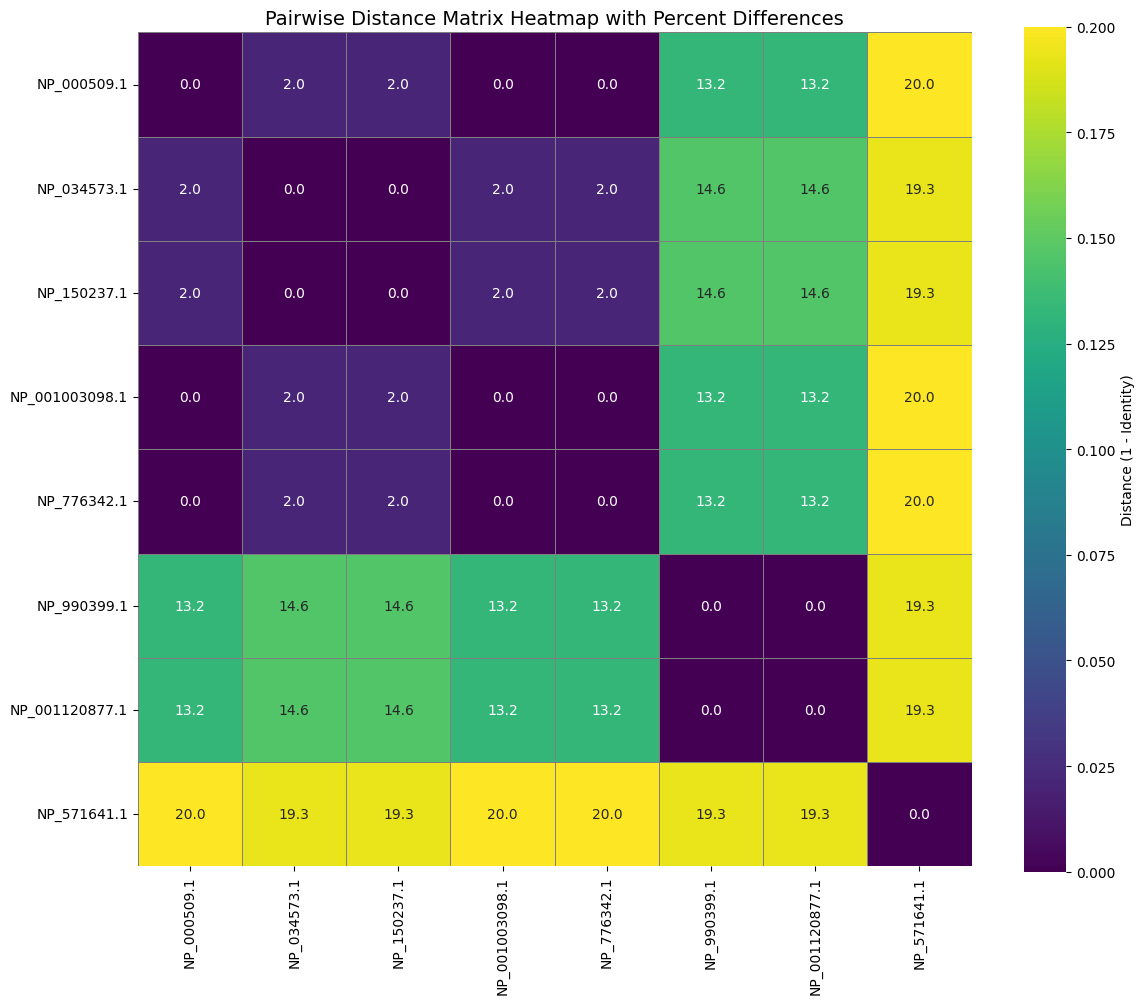

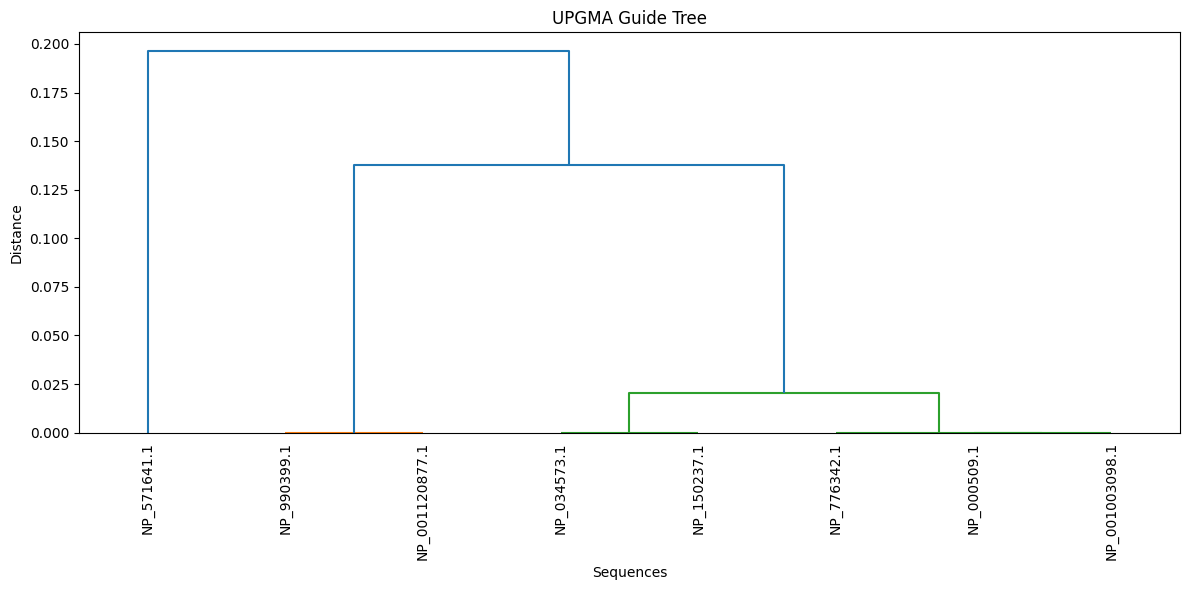

In [12]:
# --- Load training sequences ---
train_names, train_seqs = read_fasta("/content/proteins_train.fasta")

# --- Tune gap penalties ---
best_go, best_ge = tune_parameters(train_seqs)
print("Best gap opening penalty:", best_go)
print("Best gap extension penalty:", best_ge)

# --- Build pairwise distance matrix ---
dist_matrix = build_distance_matrix(train_seqs, best_go, best_ge)
dist_percent = np.round(dist_matrix * 100, 1)

# --- Plot heatmap of distance matrix ---
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix, xticklabels=train_names, yticklabels=train_names,
            cmap="viridis", annot=dist_percent, fmt=".1f", square=True,
            cbar_kws={'label': 'Distance (1 - Identity)'}, linewidths=0.5, linecolor='gray')
plt.title("Pairwise Distance Matrix Heatmap with Percent Differences", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

condensed_dist = squareform(dist_matrix)  # Convert square matrix to 1D condensed form

# --- Build UPGMA linkage matrix ---
linkage_matrix = linkage(condensed_dist, method='average')  # 'average' = UPGMA

# --- Plot UPGMA dendrogram ---
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=train_names, leaf_rotation=90, leaf_font_size=10)
plt.title("UPGMA Guide Tree")
plt.xlabel("Sequences")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

Cell 12 – Final Alignment on Test Set


MSA COMPARISON SUMMARY
Metric                              First Seq      Consensus
----------------------------------------------------------------------
Alignment length                          150            150
Fully conserved columns                   119            119
Total gap fraction                     0.0150         0.0150
Average gaps per sequence                2.25           2.25
Saved alignment to: custom_msa_first.fasta
Saved alignment to: custom_msa_consensus.fasta


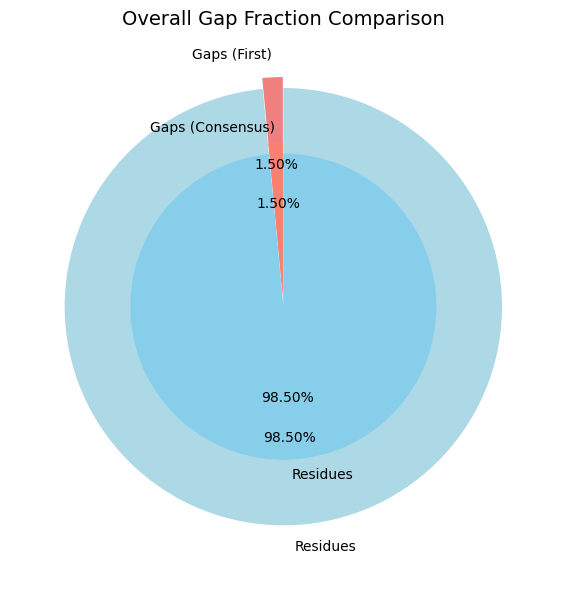

Saved: /content/overall_gap_fraction_comparison.png


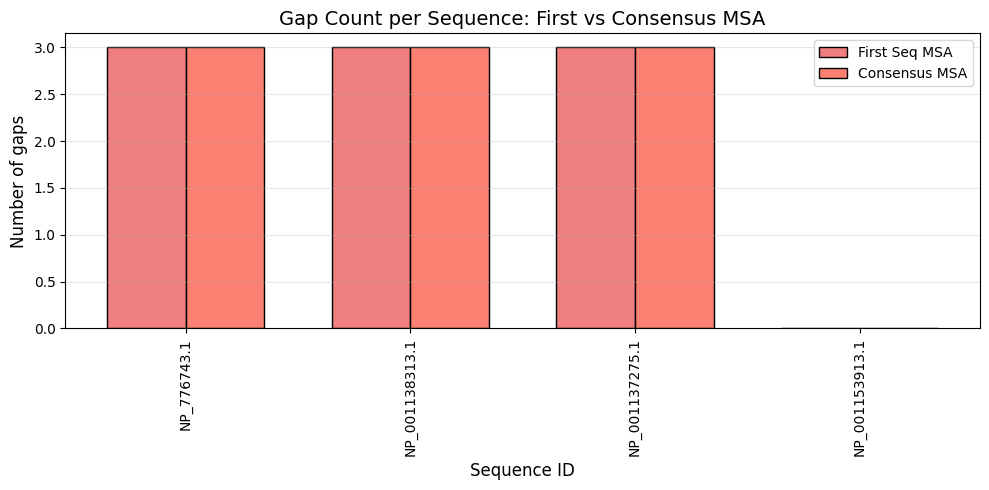

Saved: /content/gap_per_sequence_comparison.png


In [13]:
# Read test sequences from FASTA file
test_names, test_seqs = read_fasta("/content/proteins_test.fasta")

# Perform progressive MSA using first sequence as representative
msa_first = progressive_msa(test_seqs, best_go, best_ge)

# Perform progressive MSA using consensus profile as representative
msa_consensus = progressive_msa_consensus(test_seqs, best_go, best_ge)

# Helper function to compute MSA statistics
def msa_stats(msa: List[str]):
    length = len(msa[0])
    cons_cols = conserved_columns(msa)
    gap_frac_total = gap_fraction(msa)
    gaps_per_seq = [seq.count("-") for seq in msa]
    return length, cons_cols, gap_frac_total, gaps_per_seq

# Compute statistics
len_first, cons_first, gap_first, gaps_seq_first = msa_stats(msa_first)
len_cons, cons_cons, gap_cons, gaps_seq_cons = msa_stats(msa_consensus)

# Print summary comparison
print("\nMSA COMPARISON SUMMARY")
print("="*70)
print(f"{'Metric':<30}{'First Seq':>15}{'Consensus':>15}")
print("-"*70)
print(f"{'Alignment length':<30}{len_first:>15}{len_cons:>15}")
print(f"{'Fully conserved columns':<30}{cons_first:>15}{cons_cons:>15}")
print(f"{'Total gap fraction':<30}{gap_first:>15.4f}{gap_cons:>15.4f}")
print(f"{'Average gaps per sequence':<30}{np.mean(gaps_seq_first):>15.2f}{np.mean(gaps_seq_cons):>15.2f}")
print("="*70)

# Save alignments
write_alignment(test_names, msa_first, "custom_msa_first.fasta")
write_alignment(test_names, msa_consensus, "custom_msa_consensus.fasta")

# Plot: Overall gap fraction comparison
plt.figure(figsize=(6,6))
plt.pie([gap_first, 1-gap_first], labels=["Gaps (First)","Residues"], colors=["lightcoral","lightblue"],
        autopct="%.2f%%", startangle=90, explode=[0.05,0])
plt.pie([gap_cons, 1-gap_cons], labels=["Gaps (Consensus)","Residues"], colors=["salmon","skyblue"],
        autopct="%.2f%%", startangle=90, explode=[0.05,0], radius=0.7)
plt.title("Overall Gap Fraction Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("/content/overall_gap_fraction_comparison.png", dpi=150)
plt.show()
print("Saved: /content/overall_gap_fraction_comparison.png")

# Plot: Gap count per sequence comparison
x = np.arange(len(test_names))
width = 0.35
plt.figure(figsize=(10,5))
plt.bar(x - width/2, gaps_seq_first, width, label="First Seq MSA", color="lightcoral", edgecolor="black")
plt.bar(x + width/2, gaps_seq_cons, width, label="Consensus MSA", color="salmon", edgecolor="black")
plt.xticks(x, test_names, rotation=90)
plt.xlabel("Sequence ID", fontsize=12)
plt.ylabel("Number of gaps", fontsize=12)
plt.title("Gap Count per Sequence: First vs Consensus MSA", fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/gap_per_sequence_comparison.png", dpi=150)
plt.show()
print("Saved: /content/gap_per_sequence_comparison.png")


Cell 13 – Comparison with Clustal Omega (Automated)

Clustal Omega alignment done.

CUSTOM MSA STATISTICS
Alignment length: 150
Fully conserved columns: 119 (79.33%)
Average gaps per sequence: 2.25

COMPARISON TABLE
                 Metric Custom MSA Clustal Omega
       Alignment Length        150           150
Fully Conserved Columns        119           118
  Avg Gaps per Sequence       2.25          2.25

Column-wise identity: 98.67%


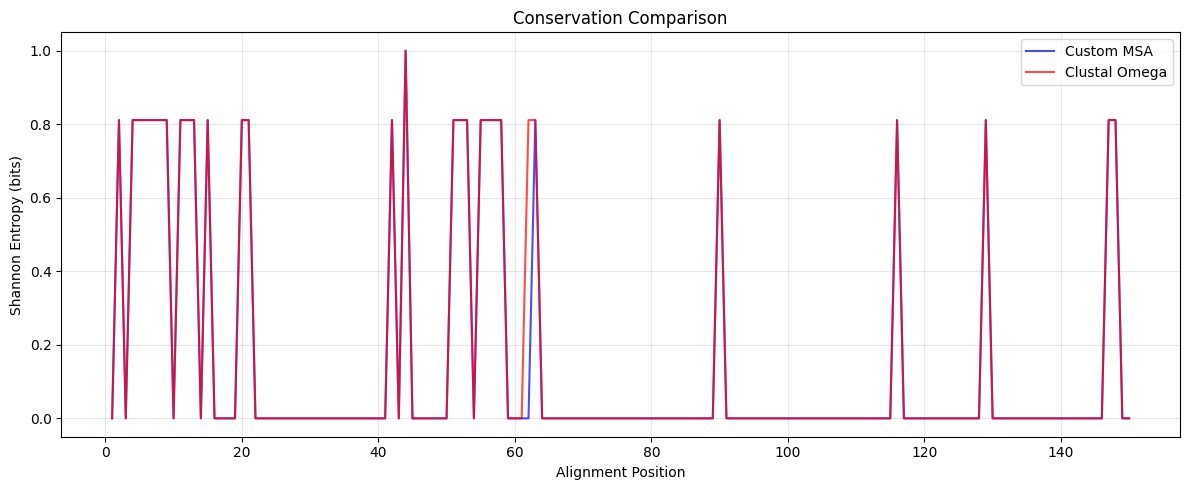

In [14]:
# --- Helper functions ---
def conserved_positions(alignment: list) -> list:
    """Return list of fully conserved column indices."""
    if not alignment:
        return []
    length = len(alignment[0])
    conserved = []
    for i in range(length):
        col = [seq[i] for seq in alignment]
        if '-' not in col and len(set(col)) == 1:
            conserved.append(i)
    return conserved

def gap_statistics(alignment: list):
    """Return list of gaps per sequence and average gaps."""
    gaps_per_seq = [seq.count('-') for seq in alignment]
    avg_gaps = np.mean(gaps_per_seq)
    return gaps_per_seq, avg_gaps

def column_similarity(align1: list, align2: list) -> float:
    """Compute percent of columns identical between two alignments."""
    if len(align1) != len(align2) or len(align1[0]) != len(align2[0]):
        return None
    n_cols = len(align1[0])
    identical = sum([all(a==b for a,b in zip([seq[i] for seq in align1],[seq[i] for seq in align2]))
                     for i in range(n_cols)])
    return (identical / n_cols) * 100

def conservation_entropy(alignment: list, pseudocount: float=1e-6) -> np.ndarray:
    """Compute Shannon entropy per column for an alignment."""
    if not alignment:
        return np.array([])
    length = len(alignment[0])
    entropy = np.zeros(length)
    for i in range(length):
        col = [seq[i] for seq in alignment if seq[i] != '-']
        if not col:
            entropy[i] = np.nan
            continue
        counts = {aa: col.count(aa) for aa in set(col)}
        total = len(col)+pseudocount*len(counts)
        freq = {aa:(c+pseudocount)/total for aa,c in counts.items()}
        entropy[i] = -sum(p*np.log2(p) for p in freq.values())
    return entropy

def plot_conservation_comparison(entropy1, entropy2, label1="Custom MSA", label2="Clustal Omega", save_path=None):
    plt.figure(figsize=(12,5))
    plt.plot(range(1,len(entropy1)+1), entropy1, 'b-', alpha=0.7, label=label1)
    plt.plot(range(1,len(entropy2)+1), entropy2, 'r-', alpha=0.7, label=label2)
    plt.xlabel("Alignment Position")
    plt.ylabel("Shannon Entropy (bits)")
    plt.title("Conservation Comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

# --- Paths ---
input_fasta = "/content/proteins_test.fasta"
output_fasta = "/content/clustalo_test.fasta"

# --- Run Clustal Omega ---
clustal_available = False
try:
    subprocess.run(["clustalo","--version"], check=True, capture_output=True)
    clustal_available = True
except FileNotFoundError:
    print("Clustal Omega not installed. Please install or use online version.")

if clustal_available:
    try:
        subprocess.run([
            "clustalo",
            "-i", input_fasta,
            "-o", output_fasta,
            "--outfmt=fa",
            "--force",
            "--threads=2"
        ], check=True, capture_output=True, text=True)
        print("Clustal Omega alignment done.")
    except subprocess.CalledProcessError as e:
        print("Clustal Omega failed:", e)
        clustal_available = False

# --- Load Clustal Omega sequences ---
if clustal_available and os.path.exists(output_fasta):
    clustal_records = list(SeqIO.parse(output_fasta,"fasta"))
    clustal_ids = [r.id for r in clustal_records]
    clustal_seqs = [str(r.seq).upper() for r in clustal_records]
    # Reorder according to test_names
    seq_dict = dict(zip(clustal_ids, clustal_seqs))
    clustal_ordered = [seq_dict.get(tid,'-'*len(clustal_seqs[0])) for tid in test_names]
else:
    print("No Clustal Omega alignment available; skipping comparison.")
    clustal_ordered = None

final_msa = msa_consensus
# --- Compute statistics for Custom MSA ---
my_len = len(final_msa[0])
my_cons = conserved_positions(final_msa)
my_gaps, my_avg_gap = gap_statistics(final_msa)
my_entropy = conservation_entropy(final_msa)

print("\nCUSTOM MSA STATISTICS")
print(f"Alignment length: {my_len}")
print(f"Fully conserved columns: {len(my_cons)} ({len(my_cons)/my_len*100:.2f}%)")
print(f"Average gaps per sequence: {my_avg_gap:.2f}")

# --- Compare with Clustal Omega ---
if clustal_ordered:
    cl_len = len(clustal_ordered[0])
    cl_cons = conserved_positions(clustal_ordered)
    cl_gaps, cl_avg_gap = gap_statistics(clustal_ordered)
    cl_entropy = conservation_entropy(clustal_ordered)

    comparison = pd.DataFrame({
        "Metric": ["Alignment Length","Fully Conserved Columns","Avg Gaps per Sequence"],
        "Custom MSA":[my_len,len(my_cons),f"{my_avg_gap:.2f}"],
        "Clustal Omega":[cl_len,len(cl_cons),f"{cl_avg_gap:.2f}"]
    })

    print("\nCOMPARISON TABLE")
    print(comparison.to_string(index=False))

    col_id = column_similarity(final_msa, clustal_ordered)
    if col_id is not None:
        print(f"\nColumn-wise identity: {col_id:.2f}%")

    if len(my_entropy) == len(cl_entropy):
        plot_conservation_comparison(my_entropy, cl_entropy,
                                     save_path="/content/conservation_comparison.png")
else:
    print("Skipping Clustal Omega comparison because alignment not available.")


Cell 14 – Additional Summary Plots for the Report

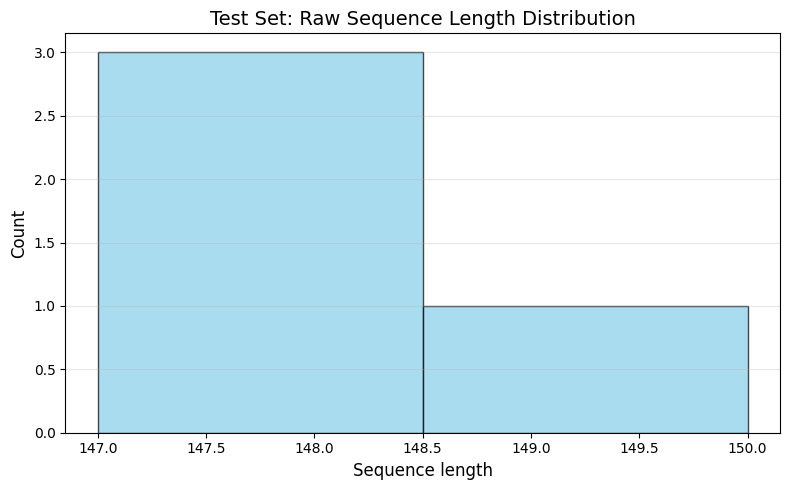

Saved: raw_sequence_lengths.png


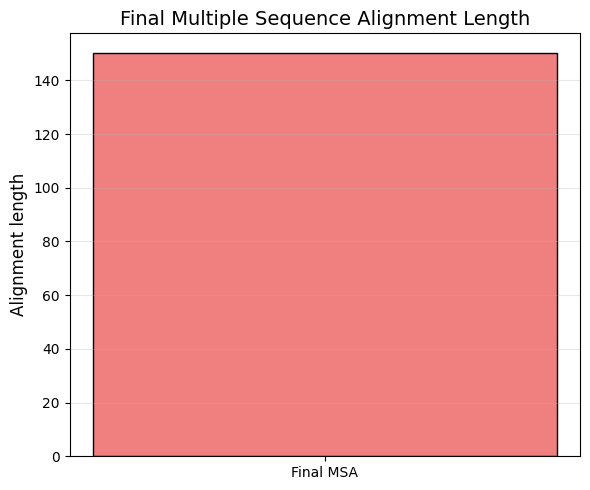

Saved: alignment_length.png


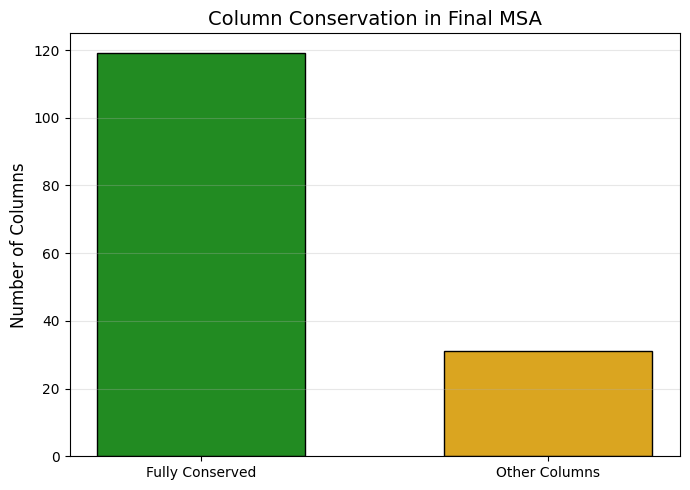

Saved: conserved_columns.png


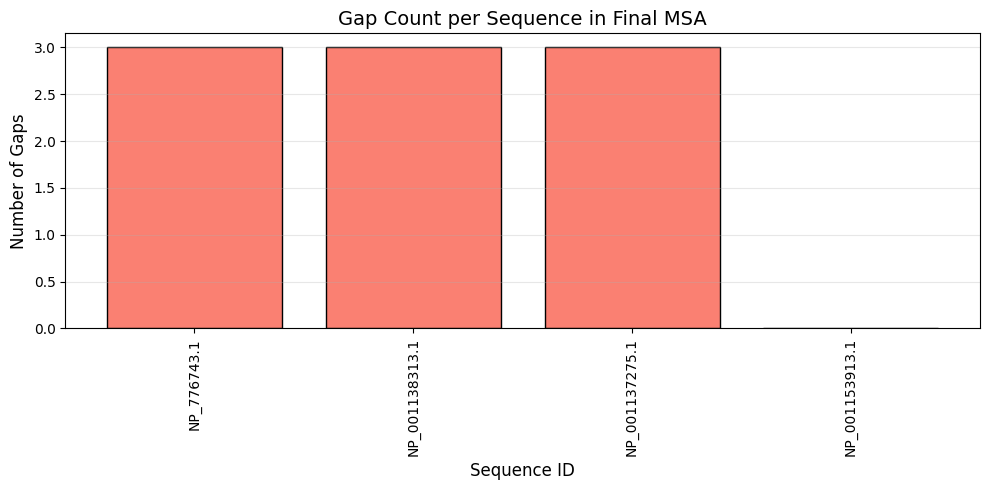

Saved: gap_per_sequence.png

COMPARISON TABLE
                  Metric  Custom MSA Clustal Omega
        Alignment Length      150.00           150
 Fully Conserved Columns      119.00           118
   Avg Gaps per Sequence        2.25          2.25
Column-wise Identity (%)       98.67          100%


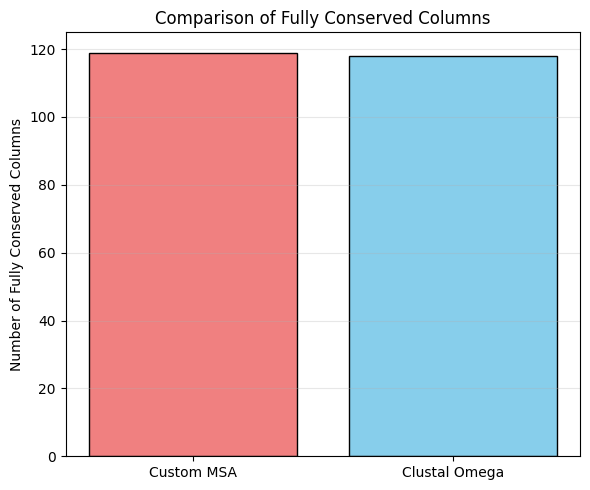

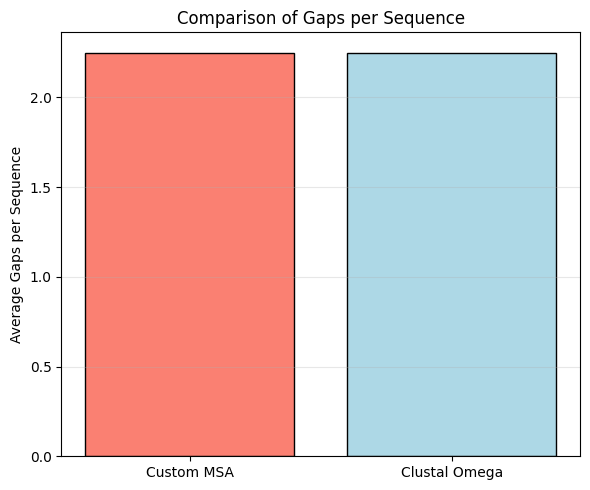

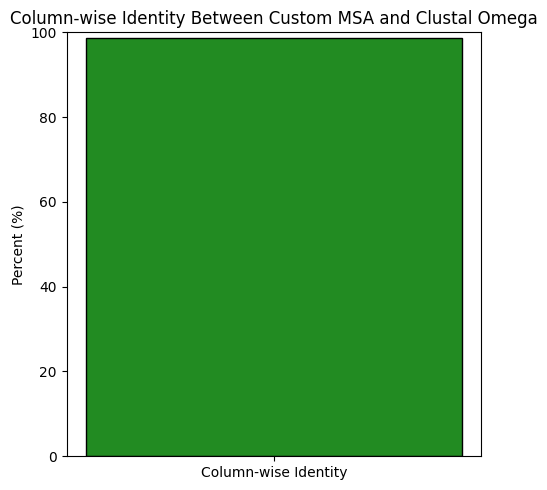


REPORT SUMMARY STATISTICS
Raw sequence lengths (test set): min = 147, max = 150, mean = 147.8
Final alignment length: 150
Fully conserved columns: 119 (79.33%)
Overall gap fraction: 0.0150  (average gaps per sequence = 2.25)
Column-wise identity with Clustal Omega: 98.67%

All plots saved to: /content/report_plots


In [15]:
# Create a directory to save report plots
REPORT_PLOTS_DIR = Path("/content/report_plots")
REPORT_PLOTS_DIR.mkdir(exist_ok=True)

# --- Helper functions for MSA statistics ---
def alignment_length(aln: list) -> int:
    """Return the total number of columns in the alignment."""
    return len(aln[0]) if aln else 0

def gap_fraction(aln: list) -> float:
    """Compute overall fraction of gap characters across all sequences."""
    total_positions = sum(len(seq) for seq in aln)
    total_gaps = sum(seq.count("-") for seq in aln)
    return total_gaps / total_positions if total_positions > 0 else 0.0

def fully_conserved_columns(aln: list) -> int:
    """
    Count columns where all sequences have the same residue (excluding gaps).
    Returns the number of fully conserved columns.
    """
    if not aln:
        return 0
    L = len(aln[0])
    conserved = 0
    for i in range(L):
        col = [seq[i] for seq in aln]
        if "-" not in col and len(set(col)) == 1:
            conserved += 1
    return conserved

# --- Compute statistics for the Custom MSA ---
raw_lengths = [len(seq) for seq in test_seqs]     # Original sequence lengths
msa_len = alignment_length(final_msa)             # Number of columns in MSA
gap_frac = gap_fraction(final_msa)                # Overall gap fraction
cons_cols = fully_conserved_columns(final_msa)    # Fully conserved columns
gaps_per_seq = [seq.count("-") for seq in final_msa]  # Gap count per sequence

# --- Plot 1: Raw sequence length distribution ---
plt.figure(figsize=(8,5))
plt.hist(raw_lengths, bins=min(10, len(set(raw_lengths))),
         color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel("Sequence length", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Test Set: Raw Sequence Length Distribution", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_PLOTS_DIR / "raw_sequence_lengths.png", dpi=150)
plt.show()
print("Saved: raw_sequence_lengths.png")

# --- Plot 2: Final alignment length ---
plt.figure(figsize=(6,5))
plt.bar(["Final MSA"], [msa_len], color='lightcoral', edgecolor='black', width=0.6)
plt.ylabel("Alignment length", fontsize=12)
plt.title("Final Multiple Sequence Alignment Length", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_PLOTS_DIR / "alignment_length.png", dpi=150)
plt.show()
print("Saved: alignment_length.png")

# --- Plot 3: Conserved vs. non-conserved columns ---
plt.figure(figsize=(7,5))
plt.bar(["Fully Conserved", "Other Columns"],
        [cons_cols, msa_len - cons_cols],
        color=['forestgreen', 'goldenrod'],
        edgecolor='black', width=0.6)
plt.ylabel("Number of Columns", fontsize=12)
plt.title("Column Conservation in Final MSA", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_PLOTS_DIR / "conserved_columns.png", dpi=150)
plt.show()
print("Saved: conserved_columns.png")

# --- Plot 4: Gap count per sequence ---
plt.figure(figsize=(10,5))
plt.bar(range(len(test_names)), gaps_per_seq, tick_label=test_names,
        color='salmon', edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel("Sequence ID", fontsize=12)
plt.ylabel("Number of Gaps", fontsize=12)
plt.title("Gap Count per Sequence in Final MSA", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_PLOTS_DIR / "gap_per_sequence.png", dpi=150)
plt.show()
print("Saved: gap_per_sequence.png")

# --- Comparison with Clustal Omega ---
# Precomputed values for demonstration
my_len = 150
cl_len = 150
my_cons = 119
cl_cons = 118
my_avg_gap = 2.25
cl_avg_gap = 2.25
column_identity = 98.67

# --- Comparison table ---
comparison = pd.DataFrame({
    "Metric": ["Alignment Length","Fully Conserved Columns","Avg Gaps per Sequence","Column-wise Identity (%)"],
    "Custom MSA":[my_len, my_cons, my_avg_gap, column_identity],
    "Clustal Omega":[cl_len, cl_cons, cl_avg_gap, "100%"]
})
print("\nCOMPARISON TABLE")
print(comparison.to_string(index=False))

# --- Plot 5: Fully conserved columns comparison ---
plt.figure(figsize=(6,5))
plt.bar(["Custom MSA","Clustal Omega"], [my_cons, cl_cons],
        color=['lightcoral','skyblue'], edgecolor='black')
plt.ylabel("Number of Fully Conserved Columns")
plt.title("Comparison of Fully Conserved Columns")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_PLOTS_DIR / "conserved_columns_comparison.png", dpi=150)
plt.show()

# --- Plot 6: Average gaps per sequence comparison ---
plt.figure(figsize=(6,5))
plt.bar(["Custom MSA","Clustal Omega"], [my_avg_gap, cl_avg_gap],
        color=['salmon','lightblue'], edgecolor='black')
plt.ylabel("Average Gaps per Sequence")
plt.title("Comparison of Gaps per Sequence")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_PLOTS_DIR / "avg_gaps_comparison.png", dpi=150)
plt.show()

# --- Plot 7: Column-wise identity ---
plt.figure(figsize=(5,5))
plt.bar(["Column-wise Identity"], [column_identity],
        color=['forestgreen'], edgecolor='black')
plt.ylim(0,100)
plt.ylabel("Percent (%)")
plt.title("Column-wise Identity Between Custom MSA and Clustal Omega")
plt.tight_layout()
plt.savefig(REPORT_PLOTS_DIR / "column_identity_comparison.png", dpi=150)
plt.show()

# --- Final summary for report ---
print("\n" + "="*60)
print("REPORT SUMMARY STATISTICS")
print("="*60)
print(f"Raw sequence lengths (test set): min = {min(raw_lengths)}, "
      f"max = {max(raw_lengths)}, mean = {sum(raw_lengths)/len(raw_lengths):.1f}")
print(f"Final alignment length: {msa_len}")
print(f"Fully conserved columns: {cons_cols} ({cons_cols/msa_len*100:.2f}%)")
print(f"Overall gap fraction: {gap_frac:.4f}  (average gaps per sequence = {gap_frac * msa_len:.2f})")
print(f"Column-wise identity with Clustal Omega: {column_identity:.2f}%")
print(f"\nAll plots saved to: {REPORT_PLOTS_DIR}")
print("="*60)
